# Load data and model

In [278]:
from pathlib import Path
import os
import sys
import types
import matplotlib.pyplot as plt
import torch as tr

def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.data import build_dataloader  
from src.diffusion import DiffusionModel

DEVICE = "cpu"
print('ROOT =', ROOT)
print('DEVICE =', DEVICE)


CONFIG_PATH = "/home/guillermo/Documents/work/sinc/tesis/GenerativeAI/RNADiffusion/configs/train/default.yaml"
config = load_config(CONFIG_PATH)
config['training']['batch_size'] = max(1, int(config['training'].get('batch_size', 4)))
config['training']['num_workers'] = 0
train_loader = build_dataloader(config, partition='train', shuffle=False)
valid_loader = build_dataloader(config, partition='valid', shuffle=False)
test_loader = build_dataloader(config, partition='test', shuffle=False)
batch = next(iter(test_loader)) 
 


ROOT = /home/guillermo/Documents/work/sinc/tesis/GenerativeAI/RNADiffusion
DEVICE = cpu


In [260]:
for k,v in batch.items():
    print(f"key: {k}")
seq = batch['sequence']
emb = batch['embedding']
cond = batch['conditioning']
target = batch['contact']

key: id
key: sequence
key: length
key: embedding
key: conditioning
key: contact
key: contact_oh
key: mask


# Create masks

torch.Size([1, 4, 116])


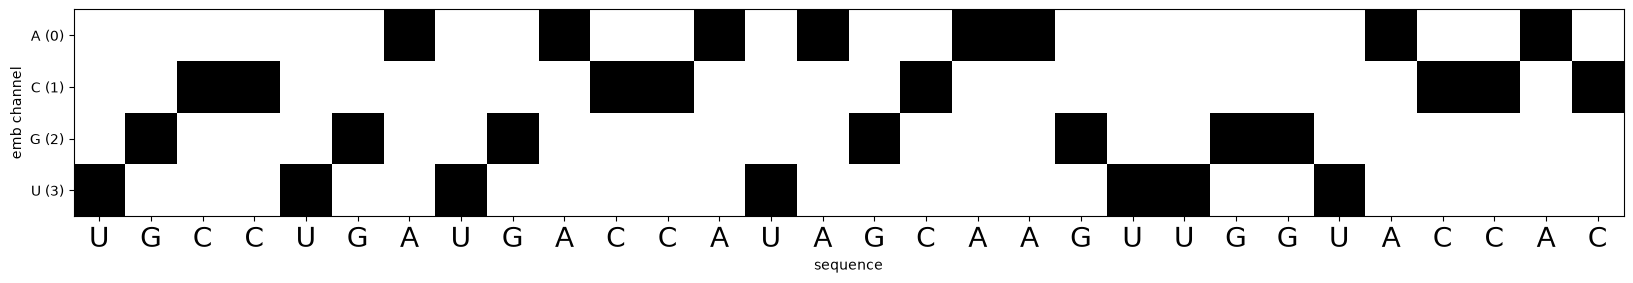

In [261]:
print(emb.shape)
b = 0; L = 30 

plt.figure(figsize=(20, 4))
plt.imshow(emb[b, :, :L].cpu(), cmap="Grays")

plt.xticks(range(L), list(seq[b][:L]), fontsize=20)
plt.yticks(range(4), ["A (0)", "C (1)", "G (2)", "U (3)"])
plt.xlabel("sequence"); plt.ylabel("emb channel"); plt.show() 

In [262]:
seqs = seq[b]   # por ejemplo "AUGCG..."

for k in range(4):
    pos = (emb[b, k] == 1).nonzero().flatten()
    nts = {seqs[i] for i in pos.tolist()}
    print(k, nts)

0 {'A'}
1 {'C'}
2 {'G'}
3 {'U'}


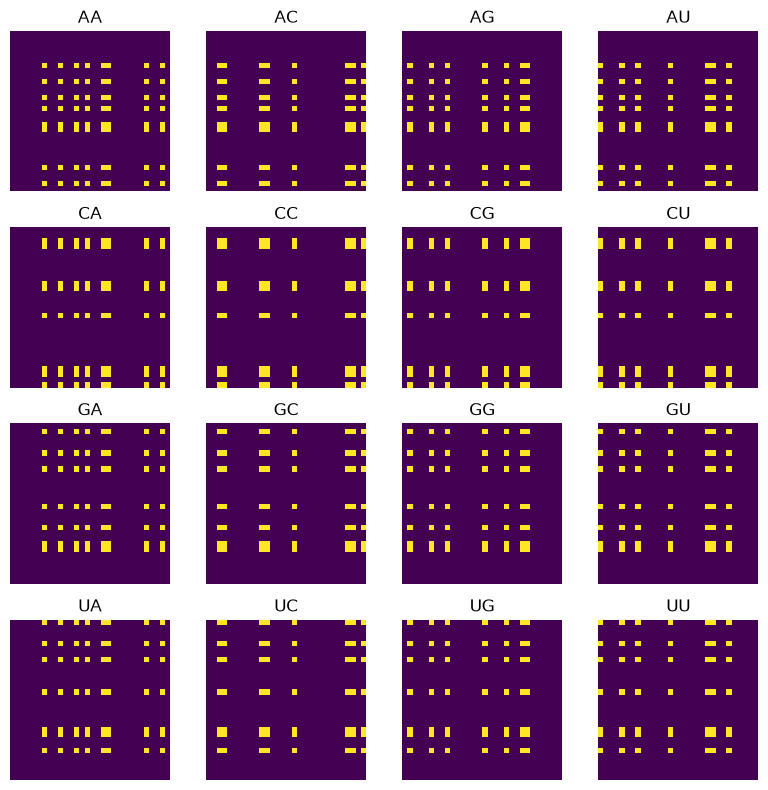

In [263]:
nts = ["A", "C", "G", "U"]

fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for a in range(4):
    for c in range(4):
        k = 4*a + c

        axs[a, c].imshow(cond[b, k, :L, :L].cpu())
        axs[a, c].set_title(f"{nts[a]}{nts[c]}")
        axs[a, c].axis("off")

plt.tight_layout()

In [264]:
outer = emb[:, :, None, :, None] * emb[:, None, :, None, :] 
outer_flat = outer.flatten(1, 2)
print(outer.shape)
print(outer_flat.shape)

# compare opterflat vs cond
tr.allclose(outer_flat, cond)

torch.Size([1, 4, 4, 116, 116])
torch.Size([1, 16, 116, 116])


True

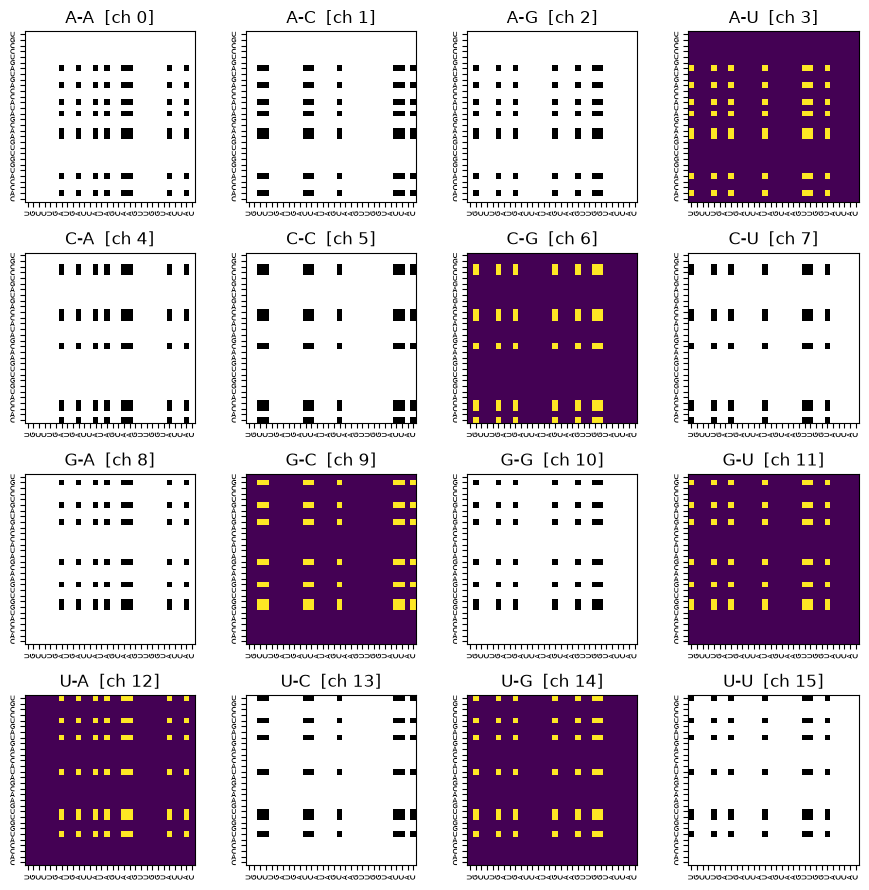

In [265]:
fig, axs = plt.subplots(4, 4, figsize=(9, 9))

valid_chanels = [3, 12, 6, 9, 11, 14]
for a in range(4):
    for c in range(4):
        k = 4*a + c
        ax = axs[a, c]
        if k not in valid_chanels:
            cmap="Grays" 
        else:
            cmap="viridis"
        ax.imshow(
            outer[b, a, c, :L, :L].cpu(),
            vmin=0,
            vmax=1,
            cmap=cmap
        )

        ax.set_title(f"{nts[a]}-{nts[c]}  [ch {k}]")

        ax.set_xticks(range(L))
        ax.set_xticklabels(seq[b][:L], fontsize=5, rotation=90)

        ax.set_yticks(range(L))
        ax.set_yticklabels(seq[b][:L], fontsize=5)
        

plt.tight_layout()

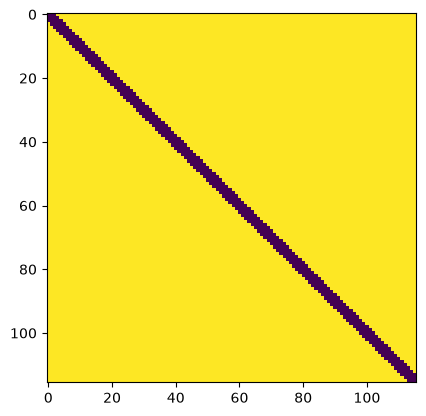

In [266]:

L = cond.shape[-1]
valid = cond[:, [3, 12, 9, 6, 11, 14], ...].sum(dim=1).bool()

eye = ~ tr.eye(L, device=cond.device, dtype=tr.bool)
for i in range(3):
    eye[i+ tr.arange(L-i),    tr.arange(L-i)] = False
    eye[   tr.arange(L-i), i+ tr.arange(L-i)] = False 
plt.imshow(eye) 

In [267]:
def valid_pair_mask(conditioning):
    # retorna mascara booleana
    # CHECKEAR CANALES
    L = conditioning.shape[-1]
    val_gu = conditioning[:, [11, 14], ...].sum(dim=1).bool()
    val_gc = conditioning[:, [6, 9], ...].sum(dim=1).bool()
    val_au = conditioning[:, [3, 12], ...].sum(dim=1).bool()
    valid  = val_au | val_gc | val_gu
    
    eye = ~ tr.eye(L, device=conditioning.device, dtype=tr.bool)
    for i in range(3):
        eye[i+ tr.arange(L-i),    tr.arange(L-i)] = False
        eye[   tr.arange(L-i), i+ tr.arange(L-i)] = False 
    L = conditioning.shape[-1]
    dist = tr.triu(
        tr.ones(L, L, device=conditioning.device, dtype=tr.bool),
        diagonal=4,
    )
    return val_gu, val_gc, val_au, eye, dist, valid
    # return dist & valid
    # return valid & eye
val_gu, val_gc, val_au, eye, dist, valid = valid_pair_mask(cond)
# plt.imshow(val_mask[0])
# plt.imshow(val_mask[0])

# plt.axis("off")

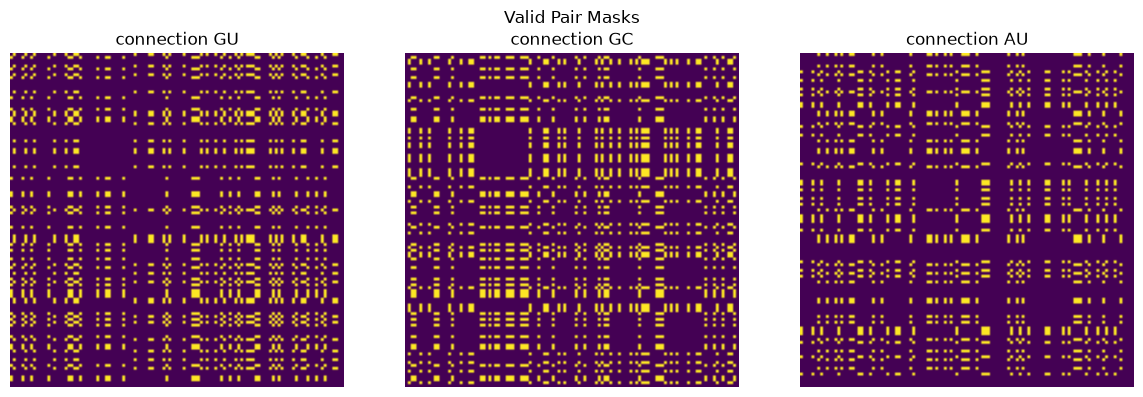

In [268]:
val_gu, val_gc, val_au, eye, dist, valid
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(val_gu[0].cpu())
ax[0].set_title("connection GU")
ax[1].imshow(val_gc[0].cpu())
ax[1].set_title("connection GC")
ax[2].imshow(val_au[0].cpu())
ax[2].set_title("connection AU")
fig.suptitle("Valid Pair Masks")
for a in ax:
    a.axis("off")
fig.tight_layout()
plt.show()



In [357]:
def valid_mask(conditioning, mode="all"):
    if mode not in ["all", "pair", "eye"]:
        raise ValueError(f"Invalid mode: {mode}. Must be one of ['all', 'pair', 'eye']")
    
    L = conditioning.shape[-1]
    val_gu = conditioning[:, [11, 14], ...].sum(dim=1).bool()
    val_gc = conditioning[:, [6, 9], ...].sum(dim=1).bool()
    val_au = conditioning[:, [3, 12], ...].sum(dim=1).bool()
    valid  = val_au | val_gc | val_gu
    
    eye = ~ tr.eye(L, device=conditioning.device, dtype=tr.bool)
    for i in range(3):
        eye[i+ tr.arange(L-i),    tr.arange(L-i)] = False
        eye[   tr.arange(L-i), i+ tr.arange(L-i)] = False  

    if mode == "all": 
        return  valid & eye
    elif mode == "pair":
        return valid
    elif mode == "eye":
        return eye

# Balance bp Loss

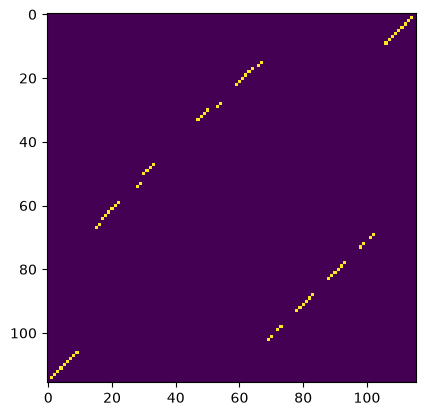

In [269]:
valid[0].shape, batch["contact_oh"][0,1].shape
vm = valid[0]
boh  = batch["contact_oh"][0,1]
plt.imshow(vm * boh)

boh_f = boh.masked_fill(~vm, 0)
plt.imshow(boh_f)

In [303]:
batch["contact"].shape , batch["contact"].sum() , -(batch["contact"] - 1).sum() 

(torch.Size([1, 116, 116]), tensor(66.), tensor(13390.))

In [304]:
import pandas as pd

contact_info = { "length" : [], "num_pos": [], "num_neg": []}
for b in train_loader:
    contact_info["length"].append(b["contact"].shape[-1])
    contact_info["num_pos"].append(b["contact"].sum().item())
    contact_info["num_neg"].append(-(b["contact"] - 1).sum().item())
for b in valid_loader:
    contact_info["length"].append(b["contact"].shape[-1])
    contact_info["num_pos"].append(b["contact"].sum().item())
    contact_info["num_neg"].append(-(b["contact"] - 1).sum().item())
for b in test_loader:
    contact_info["length"].append(b["contact"].shape[-1])
    contact_info["num_pos"].append(b["contact"].sum().item())
    contact_info["num_neg"].append(-(b["contact"] - 1).sum().item())

df = pd.DataFrame(contact_info)

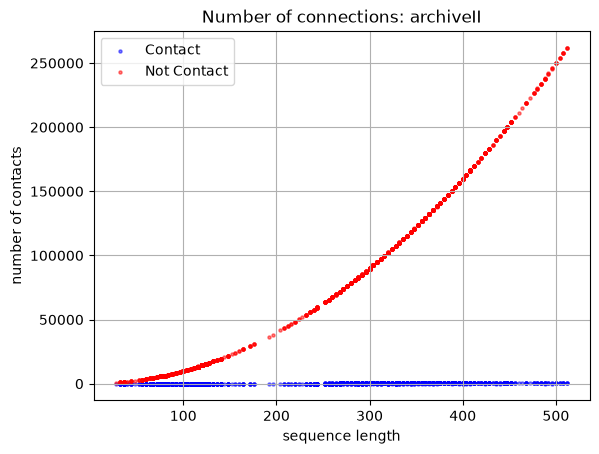

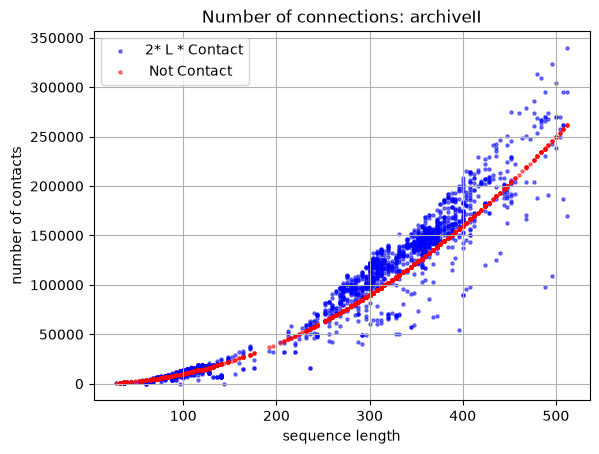

In [302]:
plt.scatter(df["length"], df["num_pos"], label="Contact", alpha=0.5,s = 5, color="blue")
plt.scatter(df["length"], df["num_neg"], label="Not Contact", alpha=0.5,s = 5, color="red")
plt.xlabel("sequence length")
plt.ylabel("number of contacts") 
plt.legend()
plt.title("Number of connections: archiveII")
plt.grid()
plt.show()

plt.scatter(df["length"], 2 * df["length"] * df["num_pos"], label="2* L * Contact", alpha=0.5,s = 5, color="blue")
plt.scatter(df["length"], df["num_neg"] , label=" Not Contact", alpha=0.5,s = 5, color="red")
plt.xlabel("sequence length")
plt.ylabel("number of contacts") 
plt.legend()
plt.title("Number of connections: archiveII")
plt.grid()
plt.show()

In [305]:
df[["length", "num_pos", "num_neg"]].describe()

,length,num_pos,num_neg
count,3864.000000,3864.000000,3864.000000
mean,195.277433,108.772257,52527.716356
std,120.444872,69.879301,57823.183573
min,28.000000,0.000000,770.000000
25%,108.000000,60.000000,11604.000000
50%,120.000000,70.000000,14334.000000
75%,308.000000,184.000000,94670.500000
max,512.000000,332.000000,261978.000000


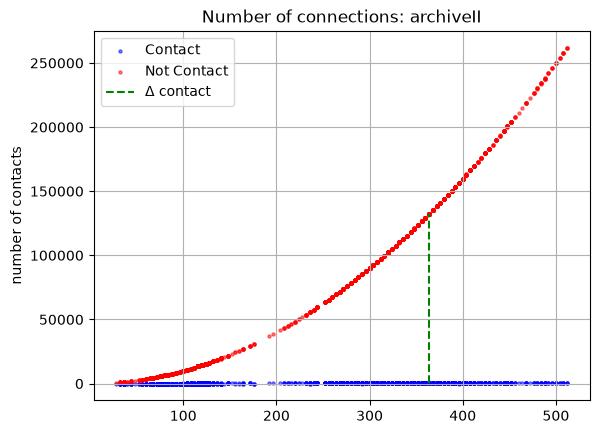

In [ ]:
df["delta"] = df["num_neg"] - df["num_pos"] 

plt.scatter(df["length"], df["num_pos"], label="Contact", alpha=0.5,s = 5, color="blue") 
plt.ylabel("number of contacts") 
plt.legend()
plt.title("Number of connections: archiveII")
plt.grid()
plt.show()

plt.scatter(df["length"], df["num_pos"], label="Contact", alpha=0.5,s = 5, color="blue")
plt.scatter(df["length"], df["num_neg"], label="Not Contact", alpha=0.5,s = 5, color="red")
# add a vline at some length, for example 100 from num_pos to num_pos+deltaL
i = 3000
plt.vlines(
    x=df["length"].iloc[i],
    ymin=df["num_pos"].iloc[i],
    ymax=df["num_pos"].iloc[i] + df["delta"].iloc[i],
    colors="green",
    linestyles="dashed", label=r"$\Delta$ contact")
plt.ylabel("number of contacts") 
plt.legend()
plt.title("Number of connections: archiveII")
plt.grid()
plt.show()

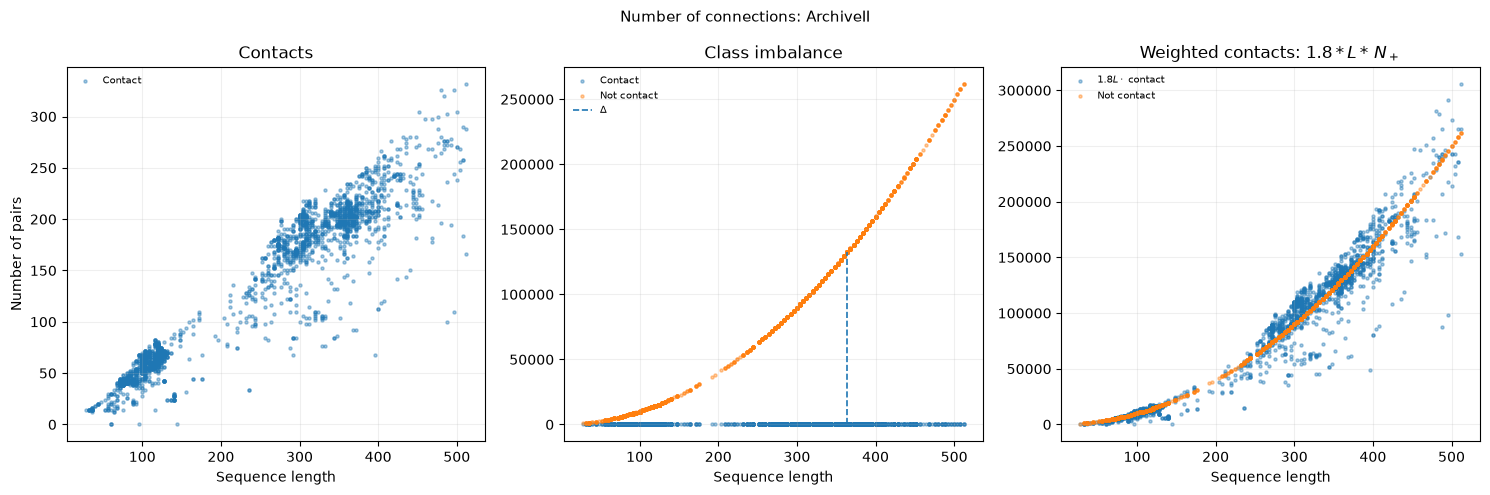

In [340]:
df["delta"] = df["num_neg"] - df["num_pos"]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# 1. Contacts
axs[0].scatter(
    df["length"], df["num_pos"],
    s=5, alpha=0.4, label="Contact"
)
axs[0].set_title("Contacts")
axs[0].set_ylabel("Number of pairs")

# 2. Contacts vs non-contacts
axs[1].scatter(
    df["length"], df["num_pos"],
    s=5, alpha=0.4, label="Contact"
)
axs[1].scatter(
    df["length"], df["num_neg"],
    s=5, alpha=0.4, label="Not contact"
)

i = 3000
x = df["length"].iloc[i]

axs[1].vlines(
    x=x,
    ymin=df["num_pos"].iloc[i],
    ymax=df["num_neg"].iloc[i],
    linestyle="--",
    linewidth=1.2,
    label=r"$\Delta$"
)

axs[1].set_title("Class imbalance")

# 3. Weighted contacts vs non-contacts
axs[2].scatter(
    df["length"],
    1.8 * df["length"] * df["num_pos"],
    s=5, alpha=0.4,
    label=r"$1.8L \cdot$ contact"
)
axs[2].scatter(
    df["length"],
    df["num_neg"],
    s=5, alpha=0.4,
    label="Not contact"
)
axs[2].set_title(r"Weighted contacts: $1.8 * L * \,N_+$")

for ax in axs:
    ax.set_xlabel("Sequence length")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=7)

fig.suptitle("Number of connections: ArchiveII", fontsize=11)
plt.tight_layout()
plt.show()

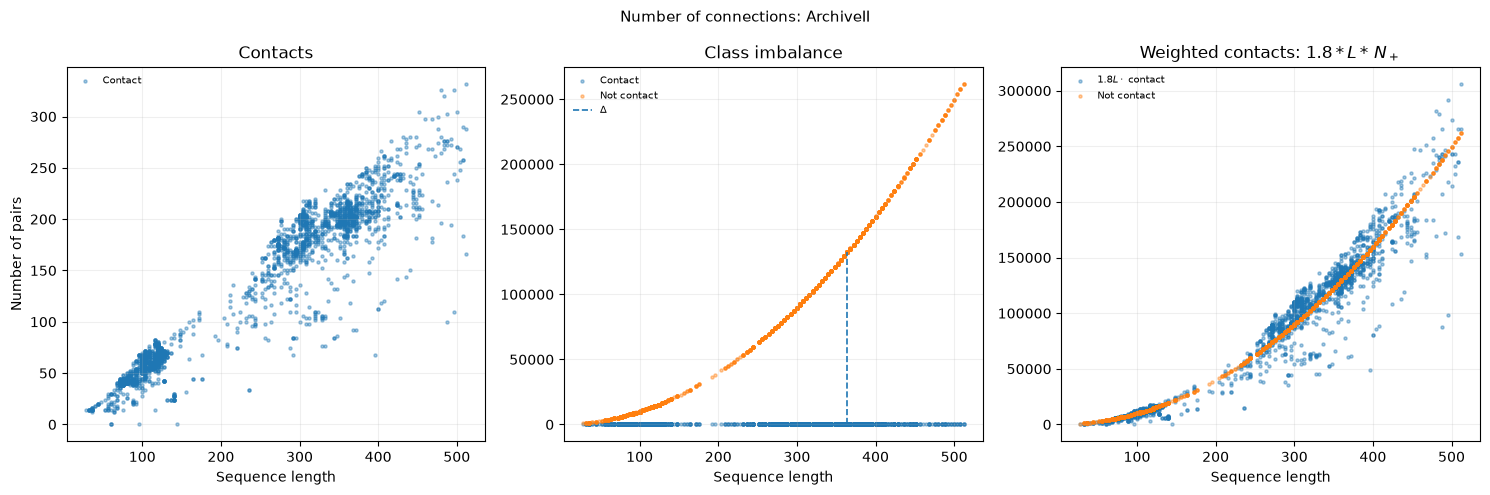

In [343]:
df["delta"] = df["num_neg"] - df["num_pos"]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# 1. Contacts
axs[0].scatter(
    df["length"], df["num_pos"],
    s=5, alpha=0.4, label="Contact"
)
axs[0].set_title("Contacts")
axs[0].set_ylabel("Number of pairs")

# 2. Contacts vs non-contacts
axs[1].scatter(
    df["length"], df["num_pos"],
    s=5, alpha=0.4, label="Contact"
)
axs[1].scatter(
    df["length"], df["num_neg"],
    s=5, alpha=0.4, label="Not contact"
)

i = 3000
x = df["length"].iloc[i]

axs[1].vlines(
    x=x,
    ymin=df["num_pos"].iloc[i],
    ymax=df["num_neg"].iloc[i],
    linestyle="--",
    linewidth=1.2,
    label=r"$\Delta$"
)

axs[1].set_title("Class imbalance")

# 3. Weighted contacts vs non-contacts
axs[2].scatter(
    df["length"],
    1 *  df["num_pos"] + 1.8 * df["length"] * df["num_pos"],
    s=5, alpha=0.4,
    label=r"$1.8L \cdot$ contact"
)
axs[2].scatter(
    df["length"],
    df["num_neg"],
    s=5, alpha=0.4,
    label="Not contact"
)
axs[2].set_title(r"Weighted contacts: $1.8 * L * \,N_+$")

for ax in axs:
    ax.set_xlabel("Sequence length")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=7)

fig.suptitle("Number of connections: ArchiveII", fontsize=11)
plt.tight_layout()
plt.show()

intercept: 1.6612249246650428
slope: 1.8383840235359334


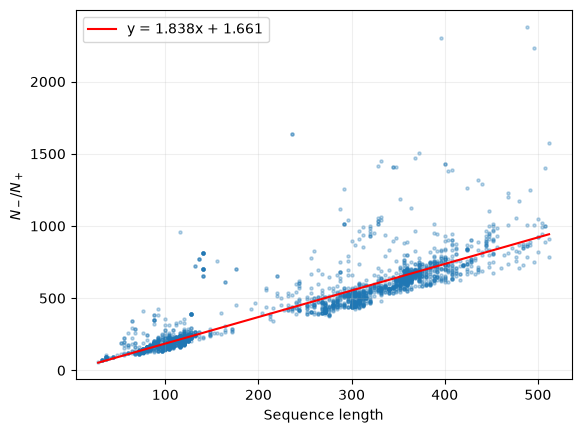

In [355]:

import numpy as np
ratio = df["num_neg"] / df["num_pos"]


x = df["length"].to_numpy(float)
y = (df["num_neg"] / df["num_pos"]).to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y)

b, a = np.polyfit(x[mask], y[mask], 1)

print("intercept:", a)
print("slope:", b)

plt.scatter(x[mask], y[mask], s=5, alpha=0.3)

xx = np.linspace(x[mask].min(), x[mask].max(), 100)
plt.plot(xx, a + b * xx, color="red", label=f"y = {b:.3f}x + {a:.3f}")

plt.xlabel("Sequence length")
plt.ylabel(r"$N_- / N_+$")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [356]:
def a(L, N_pos):
    return N_pos * (1.66 + 1.83 * L)

# Extend the model

In [ ]:
class DiffusionModel_reg_loss(DiffusionModel):
    def __init__(self, balance_bp=False, lambda_valid=False, **kwargs):
        super().__init__(**kwargs) 
        self.lambda_valid = lambda_valid   # 0.5
        self.balance_bp = balance_bp    # "linear" | "convex" | None 
    
    def convex_balance(self, lengths, a=1, c=1, length_max=512):
        l = tr.as_tensor(lengths, dtype=tr.float32)
        alpha_convex = a * (l / length_max) ** 2 + c # [B]
        return alpha_convex.mean()
    
    def linear_balance(self, lengths, lambda_w=1.8, length_max=512):
        l = tr.as_tensor(lengths, dtype=tr.float32)
        alpha_linear = 1.0 + lambda_w * (l / length_max) #[B]
        return alpha_linear.mean() 

        
    def kl_prior(self, x0_oh, lengths=None):
        eps = 1e-8

        batch_size = x0_oh.shape[0]
        device     = x0_oh.device
        ones       = tr.ones(batch_size, device=device).long()
        qxT        = self.q_pred(x0_oh, t=(self.time_steps - 1) * ones)
        half_prob  = tr.ones_like(qxT) / self.num_classes 
        p = tr.clamp(qxT, min=eps, max=1.0)
        q = tr.clamp(half_prob, min=eps, max=1.0)

        # Compute KL divergence
        kl = p * (tr.log(p) - tr.log(q))
        kl_pixelwise = tr.sum(kl, dim=1)  # [B, L, L]
        
        if lengths is None:
            return kl_pixelwise
        
        len_mask = self._lengths_to_mask(lengths,
                                        kl_pixelwise.shape[-1],
                                        device=kl_pixelwise.device
                                        ).squeeze(1)     # [B, L, L]
    
        kl_masked = kl_pixelwise * len_mask # [B, L, L]
    
        return kl_masked.sum(dim=(-1,-2)) / len_mask.sum(dim=(-1,-2))  # [B] 

    def multinomial_kl(self, p, q, condition, contact_oh, lengths=None):
        eps = 1e-8

        p = tr.clamp(p, min=eps, max=1.0)
        q = tr.clamp(q, min=eps, max=1.0)
        kl_pixelwise = (p * (tr.log(p) - tr.log(q))).sum(dim=1)  # [B, L, L]

        if self.lambda_valid > 0:
            valid_mask = valid_pair_mask(condition)
            kl_invalid = kl_pixelwise[~valid_mask].mean()
            kl_pixelwise = kl_pixelwise * valid_mask

        if lengths is None:
            return kl_pixelwise.mean()

        len_mask = self._lengths_to_mask(lengths, kl_pixelwise.shape[-1],
                                        device=kl_pixelwise.device).squeeze(1)  # [B, L, L]

        if self.balance_bp is None:
            kl_masked = kl_pixelwise * len_mask
            kl_masked = kl_masked.sum() / len_mask.sum()  # valid normalization
            return kl_masked 

        contact     =  contact_oh[:, 1, :, :].bool() & len_mask
        not_contact = ~contact_oh[:, 1, :, :].bool() & len_mask

        kl_pos = (kl_pixelwise * contact).sum()     / (contact.sum()     + eps) # tp
        kl_neg = (kl_pixelwise * not_contact).sum() / (not_contact.sum() + eps) # tn

        if self.balance_bp == "linear":
            alpha = self.linear_balance(lengths)
            loss = alpha * kl_pos + kl_neg 

        elif self.balance_bp == "convex":
            alpha = self.convex_balance(lengths)
            loss = alpha * kl_pos + (1 - alpha) * kl_neg 

        if self.lambda_valid > 0:
            loss = loss + self.lambda_valid * kl_invalid

        return loss

    def compute_vlb(self, contact_oh, xt, t, condition, lengths=None, **kwargs):
            """
            Calcula VLB considerando la máscara de padding.
            mask: Tensor [B, 1, L, L] (1=Valido, 0=Padding)
            """
            # 1. Posterior Real
            true_posterior = self.q_posterior(contact_oh, xt, t) 
            
            # 2. Posterior Predicha
            pred_x0_probs = self.predict_start(xt, t, condition, lengths=lengths, return_logits=False)
            pred_posterior = self.q_posterior(pred_x0_probs, xt, t)
            
            return self.multinomial_kl(true_posterior,
                                        pred_posterior,
                                        condition, 
                                        contact_oh, 
                                        lengths=lengths)
        


SyntaxError: invalid syntax (705468879.py, line 65)

In [372]:
from src.layers.simpleunet import SimpleUNet
model_config = config["model"]
model = DiffusionModel_reg_loss(
        num_classes=model_config["num_classes"],
        time_steps=model_config["timesteps"],
        loss_type = model_config["loss_type"],
        balance_bp="linear",
        lambda_valid=0.5,
        model=SimpleUNet,
        in_channels=model_config["in_channels"],
        out_channels=model_config["out_channels"],
        base_dim=model_config["base_dim"],
    )


In [385]:
unet_config = {
        "in_channels": model_config["in_channels"],
        "out_channels": model_config["out_channels"],
        "base_dim": model_config["base_dim"],
}

model = DiffusionModel_reg_loss(
        num_classes=model_config["num_classes"],
        time_steps=model_config["timesteps"],
        loss_type = model_config["loss_type"],
        balance_bp="null",
        lambda_valid=0.0,
        model=SimpleUNet, **unet_config,
    ) 

In [386]:
# Celda 1: imports y config
import torch as tr
import matplotlib.pyplot as plt
from copy import deepcopy

configs = {
    "none":   {"balance_bp": None,     "lambda_valid": 0},
    "linear": {"balance_bp": "linear", "lambda_valid": 0},
    "convex": {"balance_bp": "convex", "lambda_valid": 0},
}

In [388]:
# Celda 2: imports del modelo
from copy import deepcopy
from src.layers.simpleunet import SimpleUNet 

def build_variant(balance_bp, lambda_valid=0):
    return DiffusionModel_reg_loss(
        num_classes=config["model"]["num_classes"],
        time_steps=config["model"]["timesteps"],
        loss_type=config["model"]["loss_type"],
        balance_bp=balance_bp,
        lambda_valid=lambda_valid,
        model=SimpleUNet,
        in_channels=config["model"]["in_channels"],
        out_channels=config["model"]["out_channels"],
        base_dim=config["model"]["base_dim"],
    ).to(DEVICE).eval()

model_none   = build_variant(None)
model_linear = build_variant("linear")
model_convex = build_variant("convex")

# compartir pesos
model_linear.load_state_dict(model_none.state_dict(), strict=False)
model_convex.load_state_dict(model_none.state_dict(), strict=False)

models = {"none": model_none, "linear": model_linear, "convex": model_convex}
print("modelos construidos:", list(models.keys()))

modelos construidos: ['none', 'linear', 'convex']


In [ ]:
# Celda 2b: subset de 30 elementos
from torch.utils.data import Subset, DataLoader

subset_idx = list(range(30))
train_subset = Subset(train_loader.dataset, subset_idx)
subset_loader = DataLoader(
    train_subset,
    batch_size=config["training"]["batch_size"],
    shuffle=False,
    num_workers=0,
    collate_fn=train_loader.collate_fn,  # importante: mantener el collate original
)
print(f"subset: {len(train_subset)} elementos, {len(subset_loader)} batches")

In [394]:
# Celda 3: comparar sobre N batches
N = 200
history = {name: [] for name in models}
model.loss_type = "vb_stochastic"
for i, batch in enumerate(test_loader):
    if i >= N: break
    batch = {k: v.to(DEVICE) if isinstance(v, tr.Tensor) else v for k, v in batch.items()}
    for name, model in models.items():
        # print(name)
        with tr.no_grad():
            loss = model._train_loss(
                batch["contact_oh"],
                batch["conditioning"],
                lengths=batch["length"],
            )
        history[name].append(loss.item())

for name, losses in history.items():
    print(f"{name:>8}: mean={sum(losses)/len(losses):.4f}")

KeyboardInterrupt: 

In [ ]:
# Celda 3b: entrenar N epochs sobre el subset y loggear loss
N_EPOCHS = 20

history = {name: [] for name in models}

for name, model in models.items():
    model.train()
    optimizer = tr.optim.Adam(model.parameters(), lr=1e-4)
    for epoch in range(N_EPOCHS):
        epoch_loss = 0
        for batch in subset_loader:
            batch = {k: v.to(DEVICE) if isinstance(v, tr.Tensor) else v for k, v in batch.items()}
            optimizer.zero_grad()
            loss = model._train_loss(
                batch["contact_oh"],
                batch["conditioning"],
                lengths=batch["length"],
            )
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history[name].append(epoch_loss / len(subset_loader))
    print(f"{name:>8}: done")

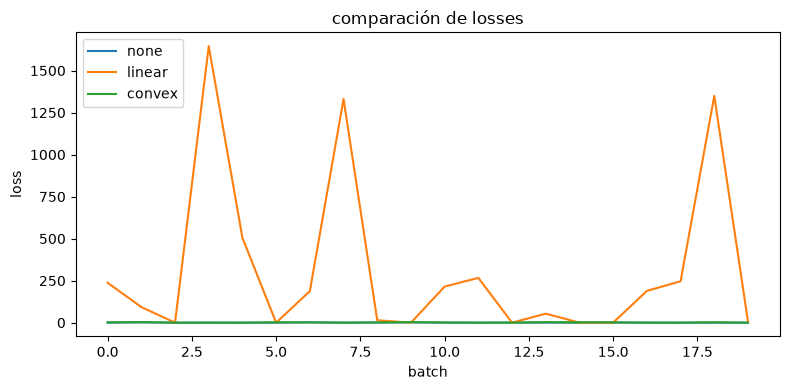

In [ ]:
# Celda 4: plot
fig, ax = plt.subplots(figsize=(8, 4))
for name, losses in history.items():
    ax.plot(losses, label=name)
ax.set_xlabel("batch")
ax.set_ylabel("loss")
ax.set_title("comparación de losses")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Celda 4b: plot
fig, ax = plt.subplots(figsize=(8, 4))
for name, losses in history.items():
    ax.plot(losses, label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title(f"overfitting sobre {len(train_subset)} ejemplos")
ax.legend()
plt.tight_layout()
plt.show()